Loading and preprocessing data...
Training the Regression Model...

--- MODEL EVALUATION ---
Mean Absolute Error: 0.93 stars
R-Squared (R2): 0.1004


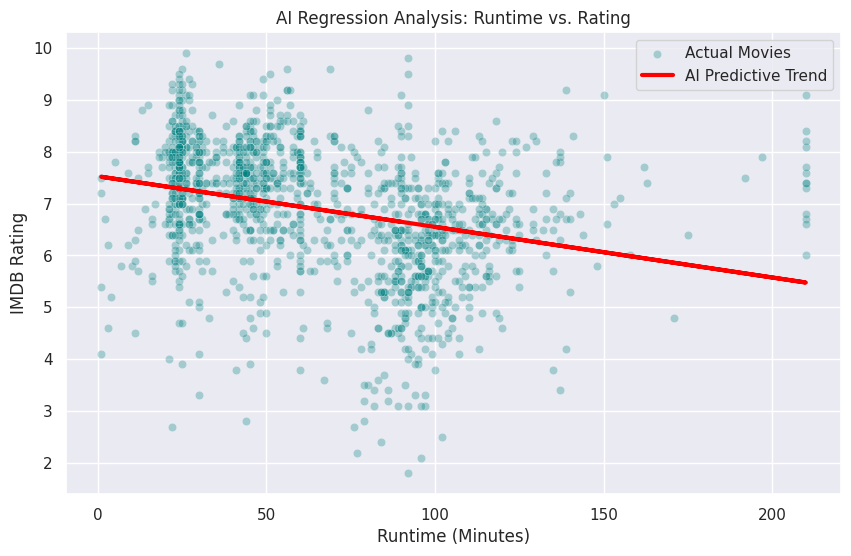

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="darkgrid")

# ==========================================
# PART 1: AUTOMATED DATA PREPARATION
# ==========================================
print("Loading and preprocessing data...")
df = pd.read_csv('/content/movies.csv')

# Drop missing runtimes and ratings (we need both to train the AI)
df.dropna(subset=['RunTime', 'RATING'], inplace=True)

# Cap extreme runtime outliers at 210 minutes
df.loc[df['RunTime'] > 210, 'RunTime'] = 210

# ==========================================
# PART 2: MACHINE LEARNING PIPELINE
# ==========================================
print("Training the Regression Model...\n")

# 1. Isolate Feature (X) and Target (y)
X = df[['RunTime']]
y = df['RATING']

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- MODEL EVALUATION ---")
print(f"Mean Absolute Error: {mae:.2f} stars")
print(f"R-Squared (R2): {r2:.4f}")

# ==========================================
# PART 3: VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['RunTime'], y=y_test, alpha=0.3, color='teal', label='Actual Movies')
plt.plot(X_test['RunTime'], y_pred, color='red', linewidth=3, label='AI Predictive Trend')
plt.title('AI Regression Analysis: Runtime vs. Rating')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('IMDB Rating')
plt.legend()
plt.show()